In [1]:
!pip install opencv-python
!pip install numpy
!pip install random
!pip install matplotlib
!pip install seaborn
!pip install -U scikit-learn

  Obtaining dependency information for opencv-python from https://files.pythonhosted.org/packages/3f/a4/d2537f47fd7fcfba966bd806e3ec18e7ee1681056d4b0a9c8d983983e4d5/opencv_python-4.10.0.84-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 37.1 MB/s eta 0:00:00:00:0100:01

[notice] A new release of pip is available: 23.2.1 -> 24.2
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 24.2
[notice] To update, run: python3 -m pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement random (from versions: none)
ERROR: No matching distribution found for random

[notice] A new release of pip is available: 23.2.1 -> 24.2
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 24.2
[notice] To update, run: python3 -m pip install --upgrade pip
  Obtaining dependency inf

In [2]:
!wget https://github.com/JaredEspinosa19/Dataset_original/archive/refs/heads/main.zip -O "Dataset_original-main.zip" && unzip -qq ./"Dataset_original-main.zip" && rm ./"Dataset_original-main.zip"

--2024-10-24 17:41:41--  https://github.com/JaredEspinosa19/Dataset_original/archive/refs/heads/main.zip
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/JaredEspinosa19/Dataset_original/zip/refs/heads/main [following]
--2024-10-24 17:41:41--  https://codeload.github.com/JaredEspinosa19/Dataset_original/zip/refs/heads/main
Resolving codeload.github.com (codeload.github.com)... 140.82.112.10
Connecting to codeload.github.com (codeload.github.com)|140.82.112.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘Dataset_original-main.zip’

Dataset_original-ma     [   <=>              ] 751.42M  28.8MB/s    in 28s     

2024-10-24 17:42:10 (27.1 MB/s) - ‘Dataset_original-main.zip’ saved [787921378]



In [3]:
print("listo")

listo


In [49]:
# Importamos las librerías necesarias

import os                   # Para manejar operaciones del sistema de archivos
import cv2                  # OpenCV para procesamiento de imágenes
import numpy as np           # Numpy para manejo de arrays y operaciones numéricas
import random                # Para la generación de números aleatorios
import tensorflow as tf      # TensorFlow para construir y entrenar modelos de Deep Learning
import matplotlib.pyplot as plt  # Para visualización de datos y gráficos
from tensorflow.keras.models import Sequential, save_model  # Para la construcción y guardado de modelos
from tensorflow.keras.layers import (Conv3D, Conv2D, Flatten, Dense, MaxPooling3D, MaxPooling2D, TimeDistributed, LSTM, Dropout, BatchNormalization)  # Capas utilizadas en el modelo
from tensorflow.keras.utils import Sequence, plot_model  # Utilidades para modelos y generación de secuencias de datos
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint  # Callbacks para mejorar el entrenamiento
from tensorflow.keras.preprocessing.image import (img_to_array, load_img, smart_resize, ImageDataGenerator)  # Preprocesamiento de imágenes
from tensorflow.keras.optimizers import Adam     # Optimizador Adam para ajustar los pesos del modelo
from sklearn.model_selection import train_test_split  # Para dividir el dataset en entrenamiento y prueba
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score)  # Métricas para evaluar el modelo
from sklearn.utils import shuffle as sk_shuffle
from collections import Counter
import seaborn as sns  # Librería para visualización avanzada de datos

# Comprobamos si hay GPUs disponibles para utilizar con TensorFlow
print("Num GPUs disponibles: ", len(tf.config.list_physical_devices('GPU')))
if tf.config.list_physical_devices('GPU'):
    print("TensorFlow utilizará GPU")  # Si hay GPU, se utiliza
else:
    print("TensorFlow utilizará CPU")  # Si no hay GPU, se utiliza CPU


# Variables globales
batch_size = 15     # Tamaño del batch
n_frames_per_sample = 18  # Número de frames por muestra, ya que cada video se ha dividido en 18 imágenes
frame_height = 128   # Altura de cada frame (en píxeles)
frame_width = 128    # Ancho de cada frame (en píxeles)
n_filters = 32       # Número de filtros para las capas convolucionales
epochs = 100          # Número de épocas para el entrenamiento del modelo
n_channels = 3       # Número de canales en las imágenes (3 para RGB)
learning_rate = 0.0001  # Tasa de aprendizaje para el optimizador Adam

# Alternativa comentada para la tasa de aprendizaje más baja:
# learning_rate = 0.0001

dataset_path = '/workspace/Dataset_original-main/Vocales'                                                                    # Ruta del dataset que se utilizará
trained_model_path = f'/workspace/100epoch/Vocal00001lr/Hybrid_vocals_{epochs}epochs_{batch_size}batchsize_00001LearningRate.keras'# Ruta para guardar o cargar el modelo entrenado
output_dir = '/workspace/100epoch/Vocal00001lr'                                                                            # Ruta para guardar las gráficas de precisión, perdida, matriz e informe de clasificación

Num GPUs disponibles:  1
TensorFlow utilizará GPU


In [50]:
class CustomDataGenerator(Sequence):
    def __init__(self, root_dir, mode='train', batch_size=32, frames_per_sample=18, target_size=(128, 128), n_channels=3, shuffle=False):
        """
        Inicializa el generador para una modalidad específica (train, validation o test).

        Parámetros:
        - root_dir: Ruta de la carpeta raíz que contiene los datos organizados por clasificación.
        - mode: Modalidad del generador ('train', 'validation', 'test').
        - batch_size: Tamaño del lote.
        - frames_per_sample: Número de frames por muestra.
        - target_size: Dimensiones de las imágenes (ancho y alto).
        - n_channels: Número de canales de color (3 para RGB).
        - shuffle: Indica si los datos deben mezclarse o no.
        """
        self.root_dir = root_dir  
        self.mode = mode
        self.batch_size = batch_size
        self.frames_per_sample = frames_per_sample
        self.target_size = target_size
        self.n_channels = n_channels
        self.shuffle = shuffle  # Establece si los datos deben mezclarse o no

        # Las clases ahora son las subcarpetas dentro del directorio raíz que representa la clasificación (vocales)
        self.classes = sorted(os.listdir(self.root_dir))
        self.class_to_index = {cls: idx for idx, cls in enumerate(self.classes)}
        
        # print(f"Clases encontradas: {self.classes}")
        
        self.dataset_info = self.prepare_dataset()
        self.samples = self.dataset_info[mode]
        # print(f"Número de muestras en {self.mode}: {len(self.samples)}")
        
        # Si shuffle es True, mezcla las muestras al inicializar el generador
        if self.shuffle:
            self.samples = sk_shuffle(self.samples)

    def __len__(self):
        """
        Define la cantidad de lotes por época.
        """
        return len(self.samples) // self.batch_size

    def prepare_dataset(self):
        """
        Prepara el dataset dividiendo las muestras en train, validation y test.
        Asegura que cada subcarpeta tiene exactamente 68 muestras (o más, ajustable según el dataset).

        Retorna:
        - Diccionario con las muestras divididas en 'train', 'validation' y 'test'.
        """
        random.seed(42) # Fija la semilla para asegurar consistencia en la división de datos
        all_files = {letter: [] for letter in self.classes}

        # Recorre cada subcarpeta (que representa una vocal: A, E, etc.)
        for letter_dir in self.classes:
            letter_path = os.path.join(self.root_dir, letter_dir)
            # print(f"Procesando letra: {letter_path}")

            sample_paths = [os.path.join(letter_path, sample_dir) for sample_dir in os.listdir(letter_path) if os.path.isdir(os.path.join(letter_path, sample_dir))]
            random.shuffle(sample_paths)  # Mezcla las muestras de forma aleatoria

            # Verificar si hay suficientes muestras (mínimo 69 en la carpeta de cada vocal)
            if len(sample_paths) >= 69:
                # print(f"    Número de muestras encontradas: {len(sample_paths)}")

                # Divide las muestras en train, validation, y test
                train_samples = sample_paths[:51]
                val_samples = sample_paths[51:60]
                test_samples = sample_paths[60:69]

                for sample_dir in train_samples:
                    frame_files = [os.path.join(sample_dir, f) for f in sorted(os.listdir(sample_dir)) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                    # print(f"    Procesando muestra de train con {len(frame_files)} imágenes en {sample_dir}")

                    if len(frame_files) == self.frames_per_sample:
                        all_files[letter_dir].append(('train', frame_files))  # Marcar como 'train'

                for sample_dir in val_samples:
                    frame_files = [os.path.join(sample_dir, f) for f in sorted(os.listdir(sample_dir)) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                    # print(f"    Procesando muestra de validation con {len(frame_files)} imágenes en {sample_dir}")

                    if len(frame_files) == self.frames_per_sample:
                        all_files[letter_dir].append(('validation', frame_files))  # Marcar como 'validation'

                for sample_dir in test_samples:
                    frame_files = [os.path.join(sample_dir, f) for f in sorted(os.listdir(sample_dir)) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                    # print(f"    Procesando muestra de test con {len(frame_files)} imágenes en {sample_dir}")
                    
                    if len(frame_files) == self.frames_per_sample:
                        all_files[letter_dir].append(('test', frame_files))  # Marcar como 'test'
                        

        # Organiza las muestras
        train, val, test = [], [], []
        for letter, samples in all_files.items():
            for sample in samples:
                mode, frame_files = sample
                if mode == 'train':
                    train.append((letter, frame_files))
                elif mode == 'validation':
                    val.append((letter, frame_files))
                elif mode == 'test':
                    test.append((letter, frame_files))

        return {'train': train, 'validation': val, 'test': test}

    def __getitem__(self, index):
        """
        Genera lotes de datos.

        Parámetros:
        - index: Índice del lote a generar.

        Retorna:
        - X_batch: Lote de imágenes.
        - y_batch: Lote de etiquetas (one-hot encoding).
        """
        batch_samples = self.samples[index * self.batch_size:(index + 1) * self.batch_size]
        X_batch = np.zeros((self.batch_size, self.frames_per_sample, *self.target_size, self.n_channels))
        y_batch = np.zeros((self.batch_size, len(self.classes)))

        # Procesa cada muestra del lote
        for i, (class_label, frames) in enumerate(batch_samples):
            class_index = self.class_to_index[class_label]

            # Carga los frames de la muestra
            images = [img_to_array(load_img(frame, color_mode='rgb', target_size=self.target_size)) / 255.0 for frame in frames]
            frames_array = np.array(images)

            X_batch[i] = frames_array
            y_batch[i, class_index] = 1   # Etiqueta one-hot

        return X_batch, y_batch

    def on_epoch_end(self):
        """
        Si shuffle está activado, mezcla las muestras al final de cada época.
        """
        if self.shuffle:
            self.samples = sk_shuffle(self.samples)





## ---------------------------------------------------------------------------------------------------------------------------- ##
## ---------------------------------------------------------------------------------------------------------------------------- ##

## FUNCIONES EXTRA (OPCIONALES) ##
#Funciones para observar los datos dentro de los generadores.

# Función para imprimir las muestras de cada partición (train, validation, test):
def print_sample_directories(generator):
    # Imprime las muestras de entrenamiento (train)
    print("Muestras en TRAIN:")
    for letter, frames in generator.dataset_info['train']:
        print(f"Clase: {letter}, Directorio de muestra: {os.path.dirname(frames[0])}")
    
    # Imprime las muestras de validación (validation)
    print("\nMuestras en VALIDATION:")
    for letter, frames in generator.dataset_info['validation']:
        print(f"Clase: {letter}, Directorio de muestra: {os.path.dirname(frames[0])}")
    
    # Imprime las muestras de prueba (test)
    print("\nMuestras en TEST:")
    for letter, frames in generator.dataset_info['test']:
        print(f"Clase: {letter}, Directorio de muestra: {os.path.dirname(frames[0])}")



# Esta función cuenta cuántas muestras hay en cada una de las particiones del dataset
def count_samples_per_division(generator):
    # Cuenta las muestras en el conjunto de entrenamiento (train)
    train_samples = len(generator.dataset_info['train'])
    
    # Cuenta las muestras en el conjunto de validación (validation)
    validation_samples = len(generator.dataset_info['validation'])
    
    # Cuenta las muestras en el conjunto de prueba (test)
    test_samples = len(generator.dataset_info['test'])
    
    # Imprime el total de muestras en cada partición
    print("\n\n")
    print(f"Total de muestras en TRAIN: {train_samples}")
    print(f"Total de muestras en VALIDATION: {validation_samples}")
    print(f"Total de muestras en TEST: {test_samples}")



# Esta función toma un batch de secuencias generadas por el generador y las visualiza.
# Por defecto, visualiza 4 secuencias, pero se puede ajustar el número de secuencias a mostrar.
def visualize_generated_sequences(generator, num_sequences=4):
    # Obtiene el primer batch del generador
    X_batch, y_batch = generator.__getitem__(0)
    
    # Asegura que no se intenten visualizar más secuencias de las que hay en el batch
    num_sequences = min(num_sequences, X_batch.shape[0])

    # Visualiza las secuencias
    for i in range(num_sequences):
        plt.figure(figsize=(15, 3))  # Ajusta el tamaño de la figura
        for j in range(generator.frames_per_sample):  # Recorre los frames de cada secuencia
            plt.subplot(1, generator.frames_per_sample, j + 1)  # Crea subplots para cada frame
            if generator.n_channels == 1:
                # Si las imágenes están en escala de grises
                plt.imshow(X_batch[i, j, :, :, 0], cmap='gray')
            else:
                # Si las imágenes están en formato RGB
                plt.imshow(X_batch[i, j, :, :, :])
            plt.axis('off')  # Oculta los ejes
        plt.show()  # Muestra las imágenes



# Código para verificar las muestras entregadas por los generadores
def contar_muestras_generador(generator):
    contador = Counter()
    for i in range(len(generator)):
        _, y_batch = generator[i]
        etiquetas = np.argmax(y_batch, axis=1)  # Obtener los índices de las clases
        for etiqueta in etiquetas:
            contador[etiqueta] += 1
    return contador

def print_sample_count(test_generator, sample_count):
    # Mapear índices a nombres de clases
    indice_a_clase = {v: k for k, v in test_generator.class_to_index.items()}

    # Imprimir el conteo de muestras por clase
    for idx, count in sample_count.items():
        print(f"Clase: {indice_a_clase[idx]}, Muestras: {count}")




## ---------------------------------------------------------------------------------------------------------------------------- ##
## ---------------------------------------------------------------------------------------------------------------------------- ##

# FUNCIÓN PARA IMPRIMIR Y GUARDAR LAS GRÁFICAS DE PRECISIÓN Y PÉRDIDA
def print_accuracy_loss(history, output_dir):
    # Sumarizar la historia de la precisión
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Precisión del modelo')
    plt.ylabel('Precisión')
    plt.xlabel('Época')
    plt.legend(['Entrenamiento', 'Validación'], loc='upper left')
    plt.savefig(f'{output_dir}/precision.png')  # Guardar la gráfica de precisión
    plt.show()
    
    # Sumarizar la historia de la pérdida
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Pérdida del modelo')
    plt.ylabel('Pérdida')
    plt.xlabel('Época')
    plt.legend(['Entrenamiento', 'Validación'], loc='upper left')
    plt.savefig(f'{output_dir}/perdida.png')  # Guardar la gráfica de pérdida
    plt.show()

# FUNCIÓN PARA IMPRIMIR Y GUARDAR LA MATRIZ DE CONFUSIÓN Y EL REPORTE DE CLASIFICACIÓN
def print_conf_matriz_classif_report(model, test_generator, output_dir):
    # Matriz de confusión e Informe de clasificación
    y_true = []
    y_pred = []

    # Recorremos el conjunto de datos de test para obtener las etiquetas reales y las predicciones
    for i in range(len(test_generator)):
        X_test, y_test = test_generator.__getitem__(i)
        preds = model.predict(X_test)

        y_true.extend(np.argmax(y_test, axis=1))  # Etiquetas reales
        y_pred.extend(np.argmax(preds, axis=1))   # Predicciones

    # Matriz de confusión
    conf_matrix = confusion_matrix(y_true, y_pred)

    # Graficar la matriz de confusión
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_to_index.keys(), yticklabels=test_generator.class_to_index.keys())
    plt.xlabel('Predicciones')
    plt.ylabel('Etiquetas verdaderas')
    plt.title('Matriz de Confusión')
    plt.savefig(f'{output_dir}/matriz_confusion.png')  # Guardar la gráfica de matriz de confusión
    plt.show()

    # Informe de clasificación
    class_report = classification_report(y_true, y_pred, target_names=test_generator.class_to_index.keys())
    
    # Guardar el informe en un archivo de texto
    with open(f'{output_dir}/classification_report.txt', 'w') as f:
        f.write(class_report)

    # Imprimir el informe en consola también
    print(class_report)
print("Cargado")

Cargado





Total de muestras en TRAIN: 255
Total de muestras en VALIDATION: 45
Total de muestras en TEST: 45


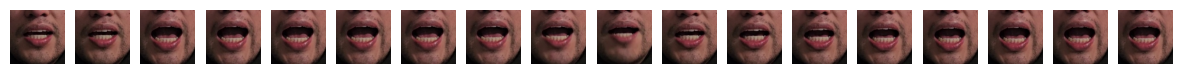

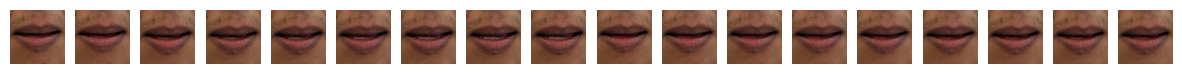

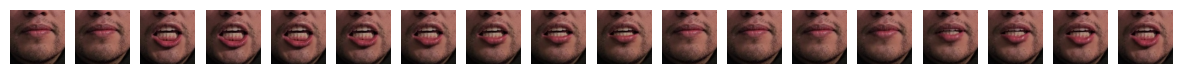

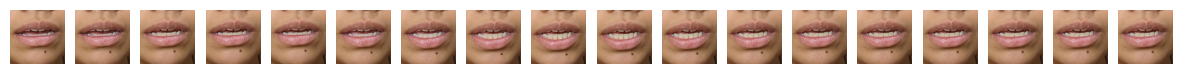

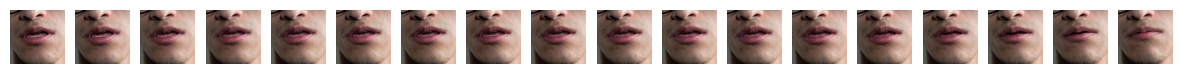

Clase: A, Muestras: 9
Clase: E, Muestras: 9
Clase: I, Muestras: 9
Clase: O, Muestras: 9
Clase: U, Muestras: 9


In [51]:
# Crear generadores para train, validation y test con la opción de shuffle
train_generator = CustomDataGenerator(dataset_path, mode='train', batch_size=batch_size, shuffle=True)
validation_generator = CustomDataGenerator(dataset_path, mode='validation', batch_size=batch_size, shuffle=False)
test_generator = CustomDataGenerator(dataset_path, mode='test', batch_size=batch_size, shuffle=False)

count_samples_per_division(train_generator)
visualize_generated_sequences(train_generator, num_sequences=5)
conteo_muestras = contar_muestras_generador(test_generator)
print_sample_count(test_generator, conteo_muestras)

In [52]:
# Optimizador con el learning rate especificado
optimizer = Adam(learning_rate=learning_rate)

# Definición del modelo
model = Sequential()

# Ajuste de las dimensiones de entrada
input_shape = (n_frames_per_sample, frame_height, frame_width, n_channels)  # Sin el batch_size

# Capas 3D Conv
model.add(Conv3D(n_filters, kernel_size=(3, 3, 3), input_shape=input_shape, activation='relu'))
model.add(Conv3D(n_filters, kernel_size=(3, 3, 3), activation='relu'))
model.add(Conv3D(n_filters, kernel_size=(3, 3, 3), activation='relu'))
model.add(MaxPooling3D(pool_size=(1, 2, 2)))
model.add(Conv3D(n_filters, kernel_size=(3, 3, 3), activation='relu'))
model.add(MaxPooling3D(pool_size=(1, 2, 2)))
model.add(Conv2D(n_filters, kernel_size=(3, 3), activation='relu'))
model.add(Conv2D(n_filters, kernel_size=(3, 3), activation='relu'))

# Capas Flatten
model.add(Flatten())

# Capas totalmente conectadas
model.add(Dense(500, activation='relu'))
model.add(Dense(500, activation='relu'))

# Número de clases (ajustar según el número de clases en tu dataset)
n_classes = len(train_generator.class_to_index)  # Ajusta este valor si es diferente
model.add(Dense(n_classes, activation='softmax'))  # Salida

# Compilación del modelo
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Resumen del modelo
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv3d_20 (Conv3D)          (None, 16, 126, 126, 32   2624      
                             )                                   
                                                                 
 conv3d_21 (Conv3D)          (None, 14, 124, 124, 32   27680     
                             )                                   
                                                                 
 conv3d_22 (Conv3D)          (None, 12, 122, 122, 32   27680     
                             )                                   
                                                                 
 max_pooling3d_10 (MaxPooli  (None, 12, 61, 61, 32)    0         
 ng3D)                                                           
                                                                 
 conv3d_23 (Conv3D)          (None, 10, 59, 59, 32)   

In [53]:
#early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Entrenamiento del modelo
history = model.fit(
    train_generator,  # Pasa el generador directamente para entrenamiento
    validation_data=validation_generator,  # Usa el generador para validación
    epochs=epochs,  # Número de épocas
    steps_per_epoch=len(train_generator),
    validation_steps=len(validation_generator)
    #callbacks=[early_stopping]
)

Epoch 1/100
17/17 [==============================] - 7s 275ms/step - loss: 1.6812 - accuracy: 0.2000 - val_loss: 1.6123 - val_accuracy: 0.2000
Epoch 2/100
17/17 [==============================] - 5s 278ms/step - loss: 1.6227 - accuracy: 0.1843 - val_loss: 1.6088 - val_accuracy: 0.2000
Epoch 3/100
17/17 [==============================] - 5s 270ms/step - loss: 1.6055 - accuracy: 0.2118 - val_loss: 1.6030 - val_accuracy: 0.2000
Epoch 4/100
17/17 [==============================] - 5s 274ms/step - loss: 1.5814 - accuracy: 0.2706 - val_loss: 1.5584 - val_accuracy: 0.2667
Epoch 5/100
17/17 [==============================] - 5s 279ms/step - loss: 1.4526 - accuracy: 0.3765 - val_loss: 1.4515 - val_accuracy: 0.3556
Epoch 6/100
17/17 [==============================] - 5s 268ms/step - loss: 1.2947 - accuracy: 0.4431 - val_loss: 1.3939 - val_accuracy: 0.3778
Epoch 7/100
17/17 [==============================] - 5s 274ms/step - loss: 1.1918 - accuracy: 0.4471 - val_loss: 1.2933 - val_accuracy: 0.3778

In [54]:
# Guarda el modelo entrenado
model.save(trained_model_path)

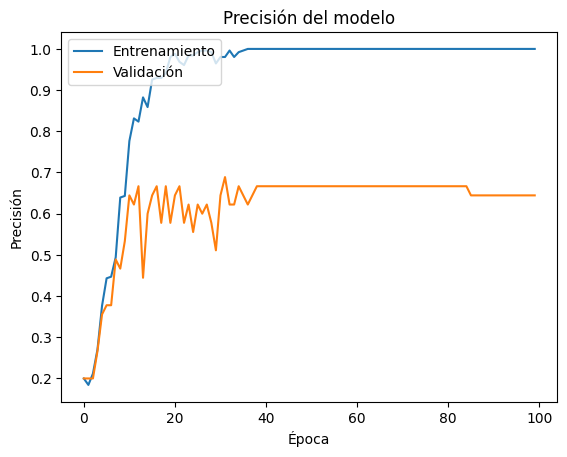

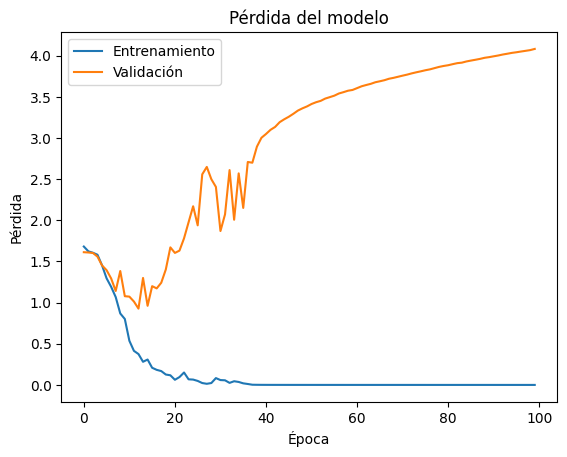

1/1 [==============================] - 0s 73ms/step


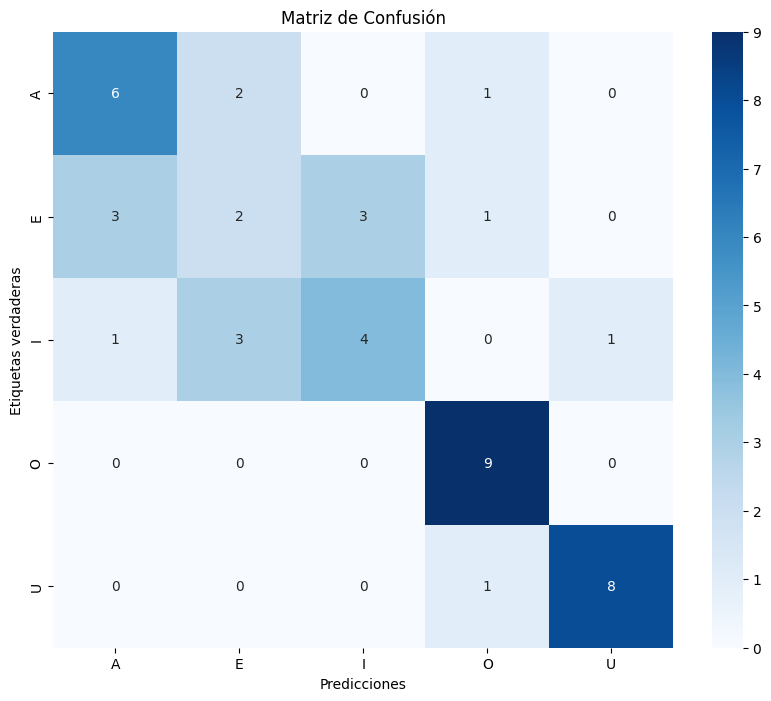

              precision    recall  f1-score   support

           A       0.60      0.67      0.63         9
           E       0.29      0.22      0.25         9
           I       0.57      0.44      0.50         9
           O       0.75      1.00      0.86         9
           U       0.89      0.89      0.89         9

    accuracy                           0.64        45
   macro avg       0.62      0.64      0.63        45
weighted avg       0.62      0.64      0.63        45



In [55]:
print_accuracy_loss(history=history, output_dir=output_dir)
print_conf_matriz_classif_report(model=model, test_generator=test_generator, output_dir=output_dir)

In [56]:
def printss(history):
    # Sumarizar la historia de la precisión
    print("accuracy\n")
    print(history.history['accuracy'])
    print("validation accuracy\n")
    print(history.history['val_accuracy'])
    print("loss\n")
    print(history.history['loss'])
    print("validation loss\n")
    print(history.history['val_loss'])
printss(history=history)

accuracy

[0.20000000298023224, 0.18431372940540314, 0.21176470816135406, 0.2705882489681244, 0.3764705955982208, 0.4431372582912445, 0.4470588266849518, 0.4941176474094391, 0.6392157077789307, 0.6431372761726379, 0.7764706015586853, 0.8313725590705872, 0.8235294222831726, 0.8823529481887817, 0.8588235378265381, 0.9254902005195618, 0.929411768913269, 0.929411768913269, 0.9411764740943909, 0.9803921580314636, 0.9882352948188782, 0.9686274528503418, 0.9607843160629272, 0.9843137264251709, 0.9843137264251709, 0.9921568632125854, 0.9960784316062927, 0.9960784316062927, 0.9921568632125854, 0.9647058844566345, 0.9803921580314636, 0.9803921580314636, 0.9960784316062927, 0.9803921580314636, 0.9921568632125854, 0.9960784316062927, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0

In [ ]:
# Función para cargar un modelo previamente entrenado
def load_trained_model(model_path):
    model = tf.keras.models.load_model(model_path)
    return model

# Cargar el modelo previamente entrenado
model = load_trained_model(trained_model_path)